# Third Alternatives and Rank Reversals

**Rank reversal** is one of the most discussed anomalies in Multi-Criteria
Decision Analysis: adding (or removing) an *irrelevant* alternative can
change the pairwise ranking between two other alternatives.  In other words,
an option that nobody would ever choose can still influence which of the
remaining options is considered best.

This is a known weakness of normalization-dependent methods such as TOPSIS,
where the ideal and anti-ideal solutions shift whenever a new row is
appended to the decision matrix.  Other methods — for example SPOTIS and
SAW — are more robust because their scores depend only on the criteria
bounds or the weight-value product, not on the full set of alternatives.

In this notebook we use VISTA maps to **visually inspect** how the
preference landscape deforms when a third alternative is introduced.

In [1]:
%matplotlib inline

from mcda_vista import (
    generate_vista,
    plot_vista,
    plot_vista_comparison,
    plot_vista_grid,
    VistaResult,
)
import numpy as np

## Baseline — No Third Alternative

First we generate a standard TOPSIS map with only the reference alternative
and the swept test point.  This is our baseline against which we will
compare all subsequent maps.

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  44%|████▍     | 1139/2601 [00:00<00:00, 11308.67pt/s]

VISTA (topsis):  87%|████████▋ | 2270/2601 [00:00<00:00, 11109.98pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 10753.25pt/s]

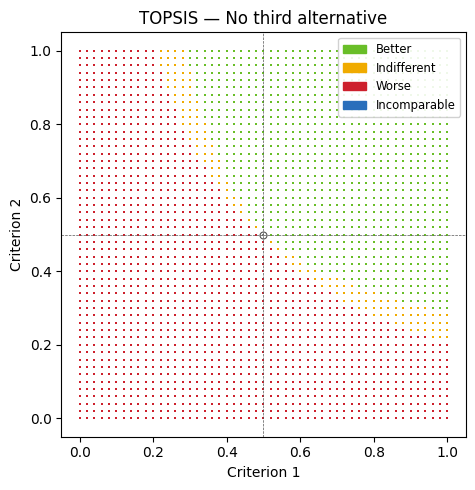

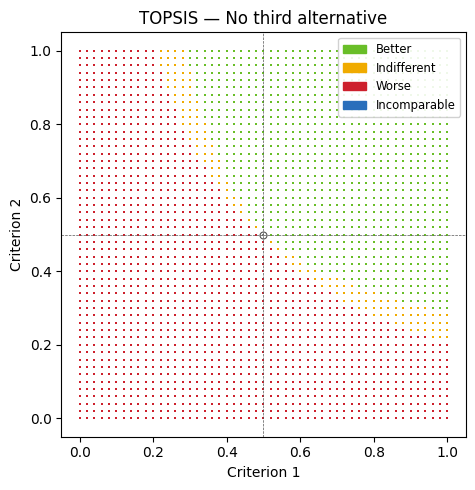

In [2]:
baseline = generate_vista("topsis", resolution=51, delta=0.10)

fig = plot_vista(baseline, title="TOPSIS \u2014 No third alternative")
fig

## Adding a Third Alternative

We now inject a single fixed third alternative at several positions in
the criterion space and regenerate the TOPSIS map each time.  The triangle
marker (\u25b2) shows the location of the third alternative.

Because TOPSIS normalizes the decision matrix, appending a row changes
the ideal and anti-ideal vectors and, consequently, the distance
calculations for *every other* alternative.  Even though the third
alternative is not directly compared, it reshapes the entire preference
landscape.

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  20%|██        | 529/2601 [00:00<00:00, 5230.43pt/s]

VISTA (topsis):  42%|████▏     | 1094/2601 [00:00<00:00, 5461.00pt/s]

VISTA (topsis):  63%|██████▎   | 1641/2601 [00:00<00:00, 5356.15pt/s]

VISTA (topsis):  86%|████████▋ | 2247/2601 [00:00<00:00, 5612.82pt/s]

...

VISTA (topsis):  39%|███▉      | 1020/2601 [00:00<00:00, 5125.68pt/s]

VISTA (topsis):  59%|█████▉    | 1533/2601 [00:00<00:00, 4793.46pt/s]

VISTA (topsis):  77%|███████▋  | 2015/2601 [00:00<00:00, 4764.63pt/s]

VISTA (topsis):  96%|█████████▌| 2493/2601 [00:00<00:00, 4632.25pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 4686.63pt/s]

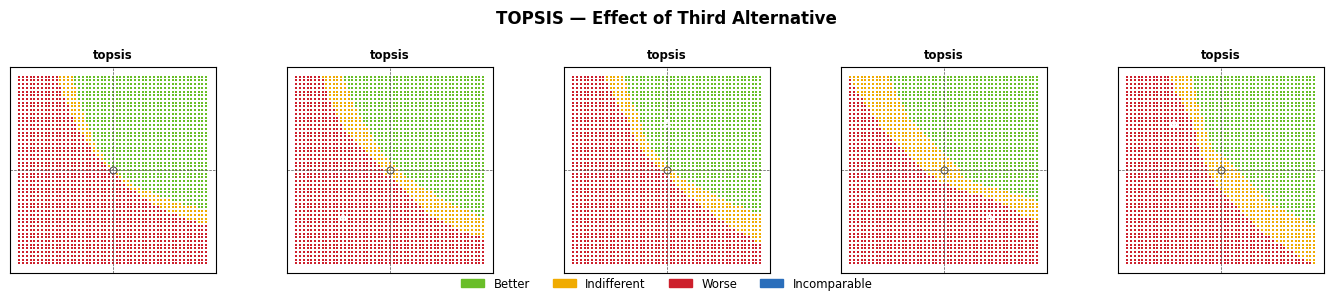

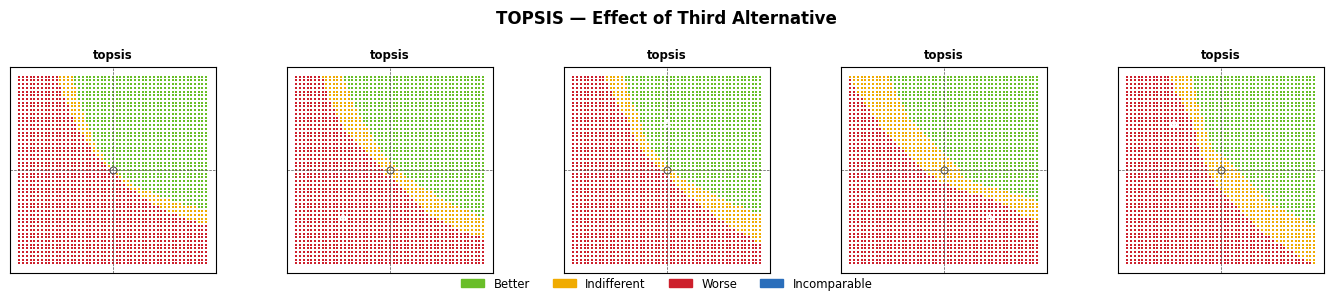

In [3]:
third_alt_positions = [
    None,
    [0.25, 0.25],
    [0.50, 0.75],
    [0.75, 0.25],
    [0.25, 0.75],
]

results_third = [
    generate_vista("topsis", resolution=51, delta=0.10, third_alternative=pos)
    for pos in third_alt_positions
]

fig = plot_vista_comparison(
    results_third,
    ncols=5,
    title="TOPSIS \u2014 Effect of Third Alternative",
)
fig

**Observations:**

- The leftmost panel (no triangle) is the baseline.  Subsequent panels
  each add a third alternative at a different location.
- Notice how the decision boundaries *deform* around the third alternative.
  In some panels regions that were previously classified as *better*
  (green) flip to *worse* (red) and vice versa \u2014 a clear rank reversal.
- The closer the third alternative is to the reference, the stronger the
  distortion.  Corner positions (e.g., `[0.25, 0.25]`) tend to stretch
  the boundary outward, while positions near the diagonal (e.g.,
  `[0.50, 0.75]`) introduce asymmetric shifts.

## Which Methods Are Affected?

Not all MCDA methods are equally susceptible to rank reversal.  Below we
compare **TOPSIS**, **SPOTIS**, and **SAW** side by side, with and without
a third alternative at `[0.25, 0.25]`.

- **TOPSIS** normalizes using the full decision matrix, making it
  inherently sensitive to added alternatives.
- **SPOTIS** computes distances from ideal solution bounds that are
  independent of other alternatives, so it should be robust.
- **SAW** (Simple Additive Weighting) multiplies weights by raw
  performance values without inter-alternative normalization, which
  limits the scope for rank reversal.

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  23%|██▎       | 587/2601 [00:00<00:00, 5837.66pt/s]

VISTA (topsis):  45%|████▌     | 1171/2601 [00:00<00:00, 5523.09pt/s]

VISTA (topsis):  67%|██████▋   | 1752/2601 [00:00<00:00, 5630.04pt/s]

VISTA (topsis):  89%|████████▉ | 2323/2601 [00:00<00:00, 5653.38pt/s]

...

VISTA (saw):  24%|██▍       | 620/2601 [00:00<00:00, 6154.53pt/s]

VISTA (saw):  48%|████▊     | 1236/2601 [00:00<00:00, 5621.18pt/s]

VISTA (saw):  69%|██████▉   | 1802/2601 [00:00<00:00, 5430.83pt/s]

VISTA (saw):  92%|█████████▏| 2391/2601 [00:00<00:00, 5584.84pt/s]

VISTA (saw): 100%|██████████| 2601/2601 [00:00<00:00, 5624.50pt/s]

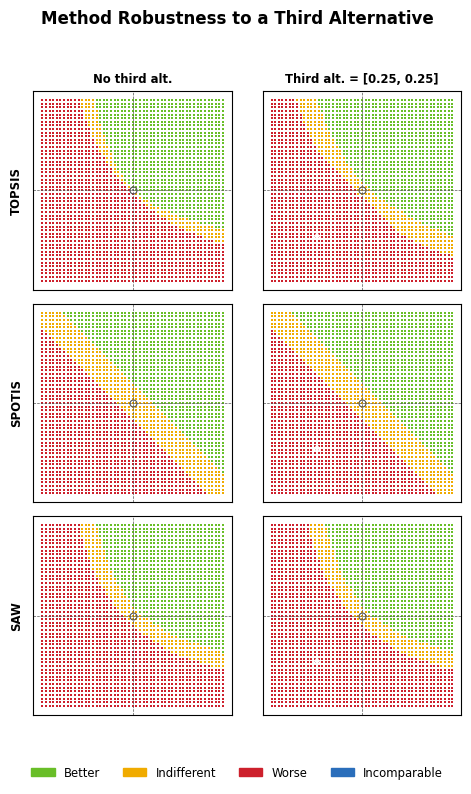

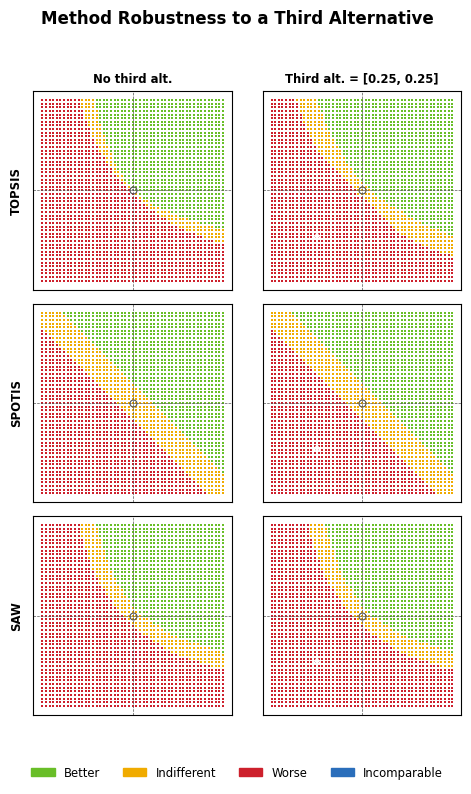

In [4]:
methods = ["topsis", "spotis", "saw"]
method_labels = ["TOPSIS", "SPOTIS", "SAW"]
third_alt = [0.25, 0.25]

grid_results = []
for m in methods:
    row = [
        generate_vista(m, resolution=51, delta=0.10),
        generate_vista(m, resolution=51, delta=0.10, third_alternative=third_alt),
    ]
    grid_results.append(row)

fig = plot_vista_grid(
    grid_results,
    row_labels=method_labels,
    col_labels=["No third alt.", "Third alt. = [0.25, 0.25]"],
    title="Method Robustness to a Third Alternative",
)
fig

**Observations:**

- **TOPSIS** shows a visible boundary shift between the two columns \u2014
  the third alternative distorts the normalization.
- **SPOTIS** and **SAW** produce virtually identical maps with and
  without the third alternative, confirming their robustness to this
  type of rank reversal.
- This demonstrates a key advantage of VISTA: it makes theoretical
  properties of MCDA methods immediately visible.

## Multiple Extra Alternatives

The `extra_alternatives` parameter lets you append several additional
alternatives at once, shown as diamond markers (\u25c6) on the plot.
Adding more alternatives can amplify normalization-based distortions.

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  22%|██▏       | 570/2601 [00:00<00:00, 5653.29pt/s]

VISTA (topsis):  44%|████▍     | 1148/2601 [00:00<00:00, 5698.49pt/s]

VISTA (topsis):  67%|██████▋   | 1732/2601 [00:00<00:00, 5740.21pt/s]

VISTA (topsis):  89%|████████▊ | 2307/2601 [00:00<00:00, 5551.82pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 5580.18pt/s]

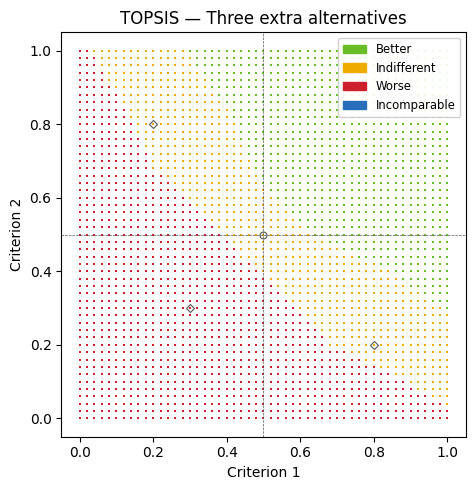

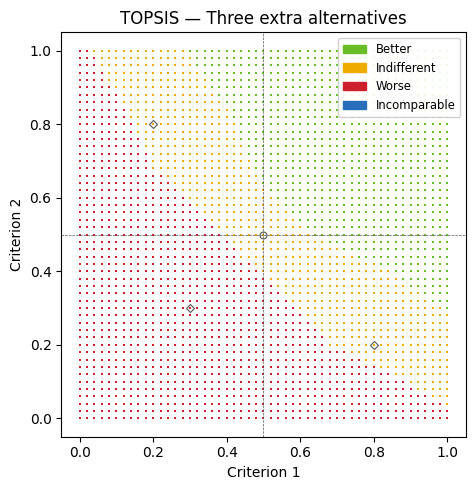

In [5]:
extras = np.array([
    [0.2, 0.8],
    [0.8, 0.2],
    [0.3, 0.3],
])

result_extras = generate_vista(
    "topsis",
    resolution=51,
    delta=0.10,
    extra_alternatives=extras,
)

fig = plot_vista(result_extras, title="TOPSIS \u2014 Three extra alternatives")
fig

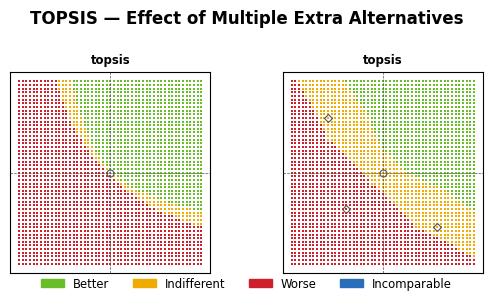

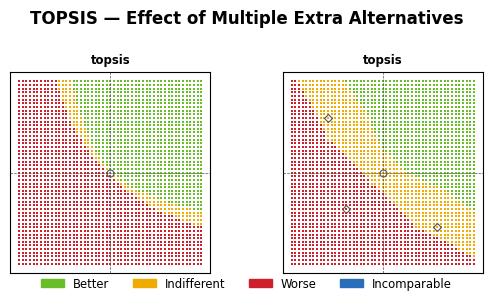

In [6]:
# Compare: no extras vs. with extras
comparison = [
    baseline,
    result_extras,
]

fig = plot_vista_comparison(
    comparison,
    ncols=2,
    title="TOPSIS \u2014 Effect of Multiple Extra Alternatives",
)
fig

**Observations:**

- The diamond markers (\u25c6) show the positions of the three extra
  alternatives.
- Compared with the baseline (left), the decision boundary in the right
  panel has shifted noticeably.  The combined effect of three additional
  points is larger than that of a single third alternative, because each
  extra row further distorts the TOPSIS normalization.
- In a real-world setting, this means that the mere act of *expanding
  the set of options under consideration* can change the recommended
  choice \u2014 even if the new options are dominated and would never be
  selected.

## Summary

- **Rank reversal** occurs when adding an irrelevant alternative changes
  the relative ranking of other alternatives.  It is a well-known
  limitation of normalization-dependent MCDA methods.
- **VISTA maps** make rank reversal visually obvious: you can directly
  compare the preference landscape with and without additional
  alternatives and spot exactly *where* the decision boundary shifts.
- **TOPSIS** is highly sensitive because its normalization recalculates
  ideal solutions from the entire decision matrix.  **SPOTIS** and
  **SAW** are far more robust.
- Use the `third_alternative` parameter to inject a single fixed
  alternative (shown as \u25b2) and `extra_alternatives` to inject
  multiple (shown as \u25c6).